# Enzyme Comparison Analysis

This notebook compares the digestion patterns of multiple enzymes using Pytato's Silico module.

## Import Libraries

In [38]:
import pytato as yt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Initialize Silico and Define Enzymes

In [39]:
# Initialize Silico
silico = yt.Silico()
silico.missed = 1  # Allow for missed cleavages

## Add Custom Enzyme(s)
silico.rules['CL3'] = '(L|Q)(?=S|A|G)'
silico.rules['Neprosin'] = 'P'

# Define enzymes to compare
enzymes = {
    "Trypsin": "trypsin",
    "GluC": "glutamyl endopeptidase",
    "Chymotrypsin": "chymotrypsin high specificity",
    "LysC": "lysc",
    "Thermolysin": "thermolysin",
    "Neprosin": "Neprosin"
}

## Import Proteome

In [40]:
# Import proteome (using a subset for faster processing)
proteome_df = yt.Silico().import_fasta()
#randomly select 1000 rows from proteome_df to generate a new dataframe
subset_proteome = proteome_df.sample(n=1000)


FASTA import complete!


## Generate Results for Each Enzyme

In [41]:
# Generate and collect results for each enzyme
results = {}
for label, enzyme in enzymes.items():
    print(f"Processing {label}...")
    peptide_properties = silico.generate_samples(
        subset_proteome,
        enzyme=enzyme,
        target="Peptide",
        identifier="Gene",
        pH=2.0,
        min_charge=2,max_length=60,min_length=7
    )
    df = pd.DataFrame(peptide_properties)
    df['enzyme'] = label
    results[label] = df

# Combine all results
combined_df = pd.concat(results.values(), ignore_index=True)

Processing Trypsin...
Proteolysis using trypsin underway.
Generating peptides...
Generated 70845 peptides matching criteria.
Processing GluC...
Proteolysis using glutamyl endopeptidase underway.
Generating peptides...
Generated 45610 peptides matching criteria.
Processing Chymotrypsin...
Proteolysis using chymotrypsin high specificity underway.
Generating peptides...
Generated 46319 peptides matching criteria.
Processing LysC...
Proteolysis using lysc underway.
Generating peptides...
Generated 42270 peptides matching criteria.
Processing Thermolysin...
Proteolysis using thermolysin underway.
Generating peptides...
Generated 60596 peptides matching criteria.
Processing Neprosin...
Proteolysis using Neprosin underway.
Generating peptides...
Generated 37147 peptides matching criteria.


## Create Comparison Plots

C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\991156545.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined_df['enzyme'].value_counts().index,


(array([    0., 10000., 20000., 30000., 40000., 50000., 60000., 70000.,
        80000.]),
 [Text(0, 0.0, '0'),
  Text(0, 10000.0, '10000'),
  Text(0, 20000.0, '20000'),
  Text(0, 30000.0, '30000'),
  Text(0, 40000.0, '40000'),
  Text(0, 50000.0, '50000'),
  Text(0, 60000.0, '60000'),
  Text(0, 70000.0, '70000'),
  Text(0, 80000.0, '80000')])

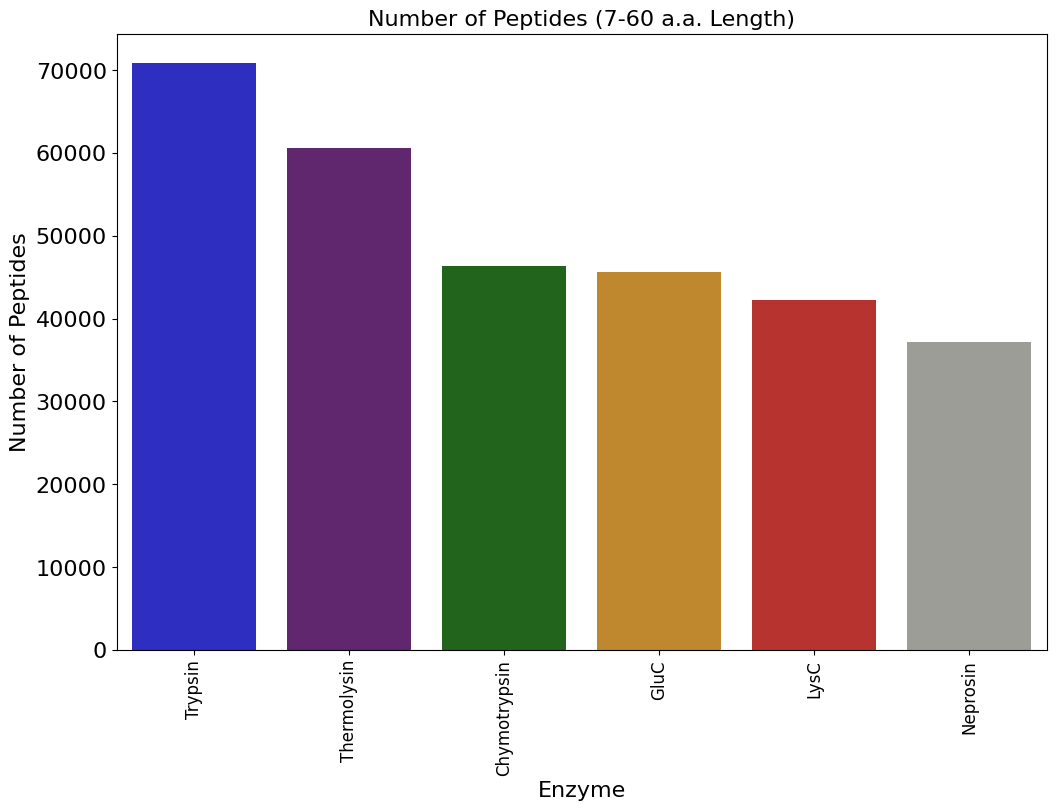

In [42]:
# Define a color map for enzymes
enzyme_colors = {
    'Trypsin': '#1616D8',
    'GluC': '#D88D16', 
    'Chymotrypsin': '#197010',
    'LysC': '#CE1D19',
    'Thermolysin': '#671B7A',
    'Neprosin': '#9E9E97'
}

# Create barplot of peptides per enzyme with consistent colors
plt.figure(figsize=(12, 8))
sns.barplot(x=combined_df['enzyme'].value_counts().index, 
           y=combined_df['enzyme'].value_counts().values,
           palette=enzyme_colors)
plt.title('Number of Peptides (7-60 a.a. Length)', fontsize=16)
plt.xlabel('Enzyme', fontsize=16)
plt.ylabel('Number of Peptides', fontsize=16)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=16)



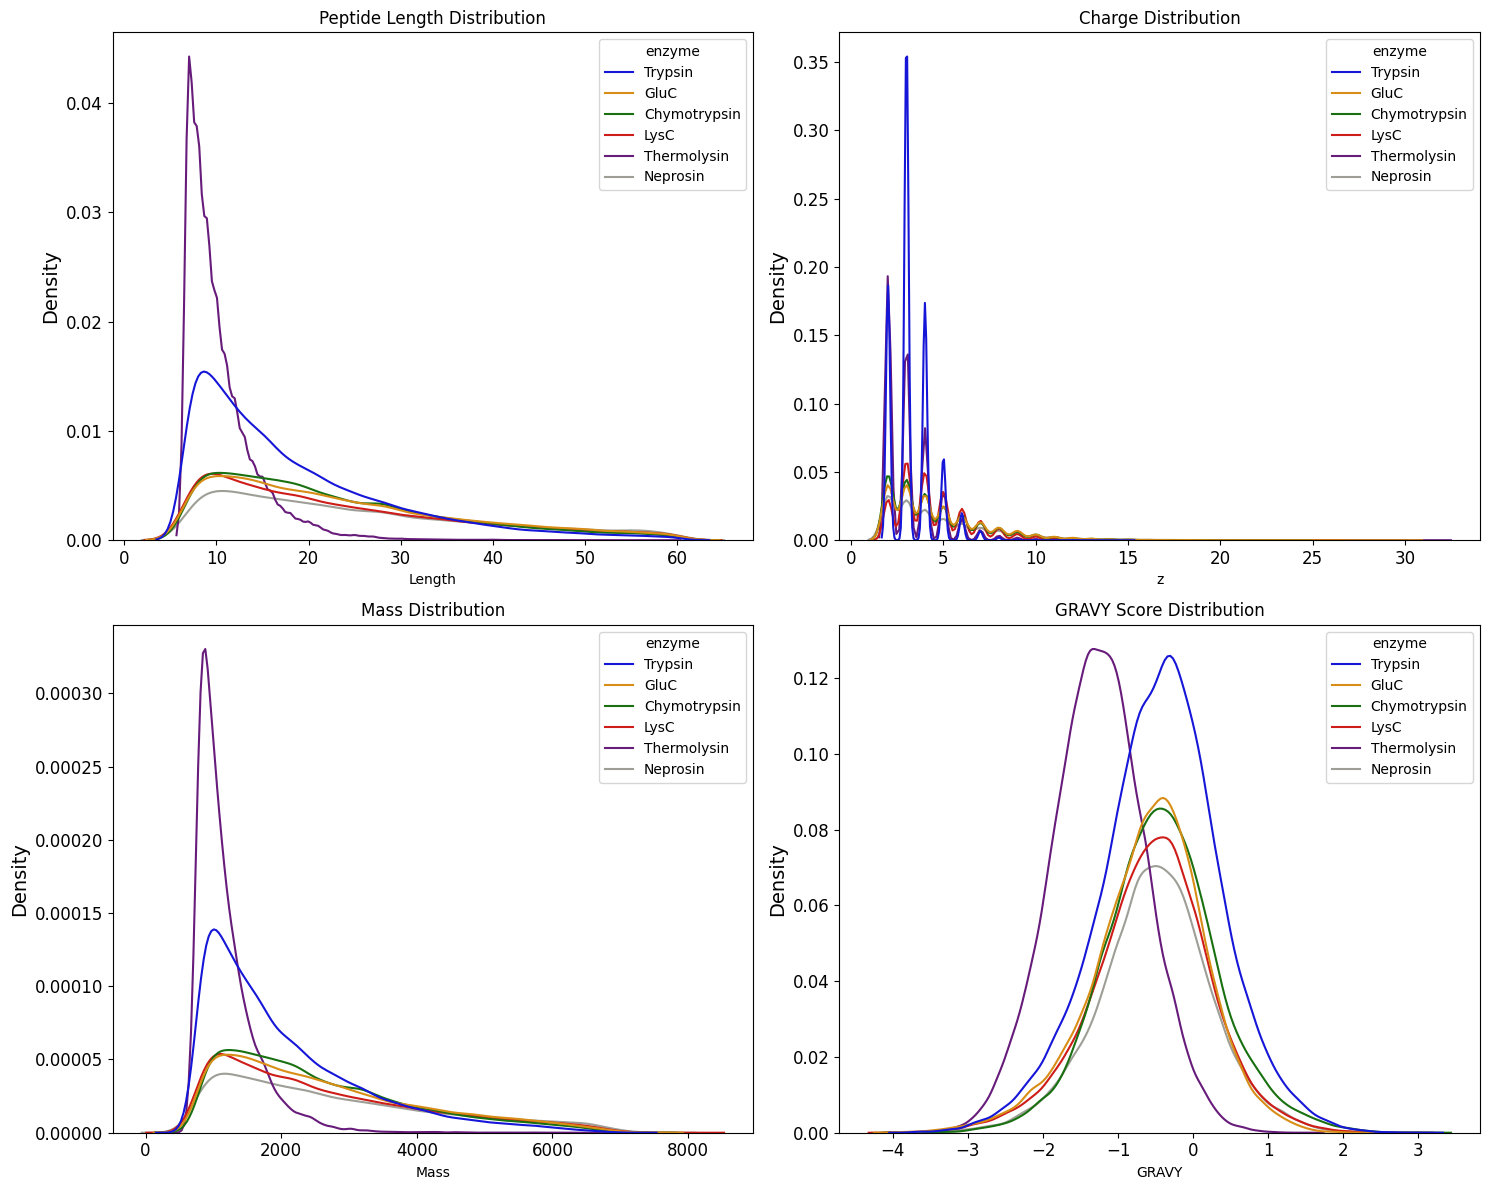

In [43]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Length distribution
sns.kdeplot(data=combined_df, x='Length', hue='enzyme', multiple="layer", ax=axes[0,0], palette=enzyme_colors)
axes[0,0].set_title('Peptide Length Distribution')
axes[0,0].set_ylabel('Density', fontsize=14)
axes[0,0].tick_params(axis='both', labelsize=12)

# Charge distribution
sns.kdeplot(data=combined_df, x='z', hue='enzyme', multiple="layer", ax=axes[0,1], palette=enzyme_colors)
axes[0,1].set_title('Charge Distribution')
axes[0,1].set_ylabel('Density', fontsize=14)
axes[0,1].tick_params(axis='both', labelsize=12)

# Mass distribution
sns.kdeplot(data=combined_df, x='Mass', hue='enzyme', multiple="layer", ax=axes[1,0], palette=enzyme_colors)
axes[1,0].set_title('Mass Distribution')
axes[1,0].set_ylabel('Density', fontsize=14)
axes[1,0].tick_params(axis='both', labelsize=12)

# GRAVY score distribution
sns.kdeplot(data=combined_df, x='GRAVY', hue='enzyme', multiple="layer", ax=axes[1,1], palette=enzyme_colors)
axes[1,1].set_title('GRAVY Score Distribution')
axes[1,1].set_ylabel('Density', fontsize=14)
axes[1,1].tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

## Summary Statistics

In [44]:
results["Trypsin"]

,Gene,peptide,Length,aa_comp,neutral_z,z,Mass,GRAVY,IPC,m/z,enzyme
0,ADNP,MFQLPVNNLGSLR,13,"{'Q': 1, 'P': 1, 'L': 3, 'R': 1, 'G': 1, 'F': ...",1,2,1470.765319,0.192308,6.500000,735.382659,Trypsin
1,ADNP,MFQLPVNNLGSLRK,14,"{'K': 1, 'Q': 1, 'P': 1, 'L': 3, 'R': 1, 'G': ...",2,3,1598.860282,-0.100000,10.044922,532.953427,Trypsin
2,ADNP,KILSDIGLEYCK,12,"{'D': 1, 'K': 2, 'I': 2, 'L': 2, 'E': 1, 'C': ...",0,3,1361.737700,0.150000,6.500000,453.912567,Trypsin
3,ADNP,ILSDIGLEYCK,11,"{'D': 1, 'K': 1, 'I': 2, 'L': 2, 'E': 1, 'C': ...",-1,2,1233.642737,0.518182,3.046875,616.821369,Trypsin
4,ADNP,ILSDIGLEYCKEHIEDFK,18,"{'D': 2, 'H': 1, 'K': 2, 'I': 3, 'L': 2, 'E': ...",-3,4,2130.093189,-0.255556,3.967285,532.523297,Trypsin
...,...,...,...,...,...,...,...,...,...,...,...
70840,YN010,MVRPHLLKK,9,"{'H': 1, 'K': 2, 'P': 1, 'L': 2, 'R': 1, 'V': ...",3,5,1102.679740,-0.377778,10.586914,220.535948,Trypsin
70841,YN010,ILGRVWWLMPVVLALWEAEVGGSLEVR,27,"{'P': 1, 'I': 1, 'L': 5, 'W': 3, 'E': 3, 'R': ...",-1,3,3056.726246,0.896296,4.024414,1018.908749,Trypsin
70842,YN010,VWWLMPVVLALWEAEVGGSLEVR,23,"{'P': 1, 'W': 3, 'L': 4, 'E': 3, 'A': 2, 'R': ...",-2,2,2617.435543,0.904348,3.097656,1308.717771,Trypsin
70843,YN010,VWWLMPVVLALWEAEVGGSLEVRSLRPAWPTW,32,"{'P': 3, 'W': 5, 'L': 5, 'E': 3, 'A': 3, 'R': ...",-1,3,3712.001693,0.481250,4.024414,1237.333898,Trypsin


In [45]:
## results to excel
## convert dictionary to excel file with each key creating a new sheet. 
# Create Excel writer object
import openpyxl
with pd.ExcelWriter('enzyme_results.xlsx') as writer:
    # Write each enzyme's results to a separate sheet
    for enzyme, df in results.items():
        df.to_excel(writer, sheet_name=enzyme, index=False)


In [46]:
# Print summary statistics
print("Summary Statistics:")
for label in enzymes.keys():
    df = results[label]
    print(f"\n{label}:")
    print(f"Total peptides: {len(df)}")
    print(f"Average length: {df['Length'].mean():.2f}")
    print(f"Average charge: {df['z'].mean():.2f}")
    print(f"Average mass: {df['Mass'].mean():.2f}")
    print(f"Average GRAVY: {df['GRAVY'].mean():.2f}")

Summary Statistics:

Trypsin:
Total peptides: 70845
Average length: 18.35
Average charge: 3.26
Average mass: 2032.47
Average GRAVY: -0.45

GluC:
Total peptides: 45610
Average length: 23.50
Average charge: 4.69
Average mass: 2630.28
Average GRAVY: -0.60

Chymotrypsin:
Total peptides: 46319
Average length: 22.74
Average charge: 4.51
Average mass: 2545.83
Average GRAVY: -0.43

LysC:
Total peptides: 42270
Average length: 23.16
Average charge: 4.46
Average mass: 2601.66
Average GRAVY: -0.57

Thermolysin:
Total peptides: 60596
Average length: 10.35
Average charge: 3.18
Average mass: 1177.11
Average GRAVY: -1.26

Neprosin:
Total peptides: 37147
Average length: 24.95
Average charge: 4.75
Average mass: 2778.14
Average GRAVY: -0.51


## Sequence Coverage

In [118]:
# Create a mapping of gene names to protein sequences
protein_sequence_map = subset_proteome.set_index('Gene')['Peptide'].to_dict()

# Function to calculate coverage
def calculate_coverage(group):
    gene = group.name  # Get the gene name from the group
    protein_sequence = protein_sequence_map[gene]  # Get the protein sequence
    peptides = group['peptide'].tolist()  # Generated peptides
    return silico.Pep2Pro(protein_sequence, peptides)

# Calculate coverage for each enzyme
coverage_data = {}
for enzyme in combined_df['enzyme'].unique():
    print(f"Processing {enzyme}...")
    # Filter data for current enzyme
    enzyme_df = combined_df[combined_df['enzyme'] == enzyme]
    # Calculate coverage for each protein
    coverage = enzyme_df.groupby('Gene').apply(calculate_coverage)
    coverage_data[enzyme] = coverage

# Create coverage matrix
coverage_matrix = pd.DataFrame(coverage_data)
coverage_matrix = coverage_matrix * 100  # Convert to percentages


Processing Trypsin...


C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\4282586576.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = enzyme_df.groupby('Gene').apply(calculate_coverage)


Processing GluC...


C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\4282586576.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = enzyme_df.groupby('Gene').apply(calculate_coverage)


Processing Chymotrypsin...


...

C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\4282586576.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = enzyme_df.groupby('Gene').apply(calculate_coverage)


Processing Thermolysin...


C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\4282586576.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = enzyme_df.groupby('Gene').apply(calculate_coverage)


Processing Neprosin...


C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\4282586576.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = enzyme_df.groupby('Gene').apply(calculate_coverage)


In [48]:
# # Create heatmap
# plt.figure(figsize=(12, 8))
# sns.heatmap(coverage_matrix, 
#             annot=False,  # Show values
#             fmt='.0f',   # Format as float with 1 decimal
#             cmap='PRGn',  # Color scheme
#             cbar_kws={'label': 'Coverage (%)'})

# plt.title('Protein Coverage by Enzyme')
# plt.xlabel('Enzyme')
# plt.ylabel('Protein')
# plt.tight_layout()
# plt.show()

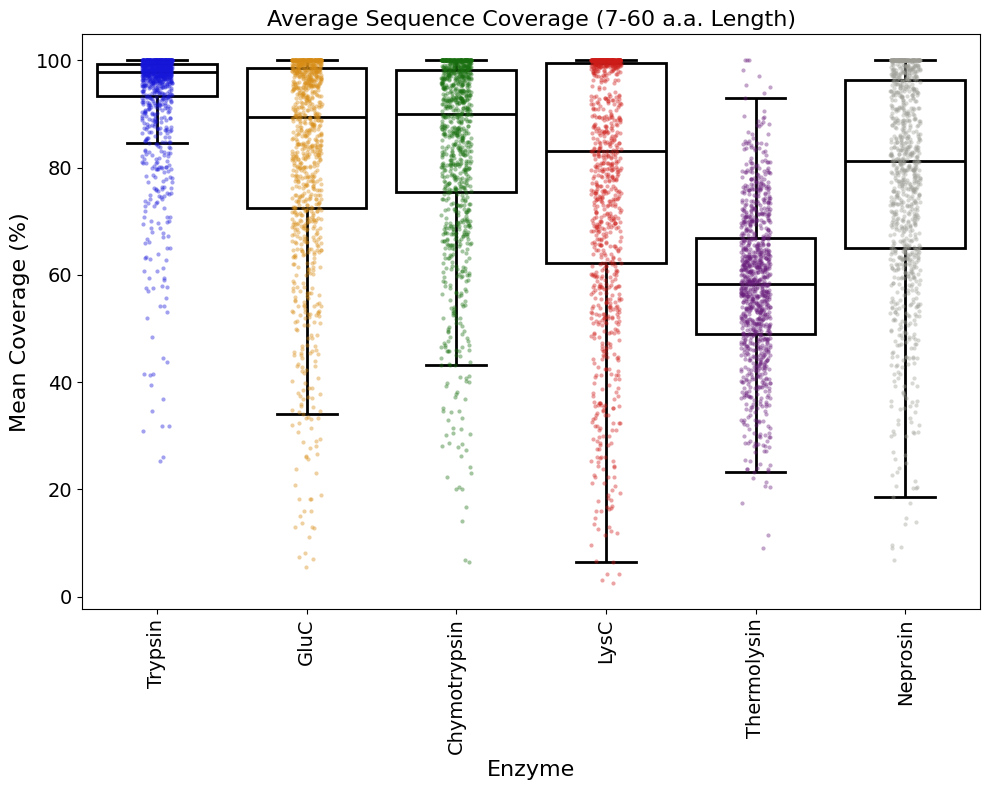

In [123]:
# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Prepare data for boxplot
enzymes = coverage_matrix.columns
coverages_flat = []
enzyme_labels = []
means = []
for enzyme in enzymes:
    coverages = coverage_matrix[enzyme].dropna()  # Remove NaN values
    means.append(np.mean(coverages))
    for cov in coverages:
        enzyme_labels.append(enzyme)
        coverages_flat.append(cov)

# Create boxplot
sns.boxplot(x=enzyme_labels, y=coverages_flat, ax=ax, color='white', fliersize=0, linewidth=2, linecolor='black')

# Overlay strip plot for individual coverage values
for enzyme in enzymes:
    coverages = coverage_matrix[enzyme].dropna()
    sns.stripplot(x=[enzyme]*len(coverages), y=coverages, ax=ax, color=enzyme_colors[enzyme], alpha=0.4, size=3, jitter=0.1)

ax.set_title('Average Sequence Coverage (7-60 a.a. Length)', fontsize=16)
ax.set_xlabel('Enzyme', fontsize=16)
ax.set_ylabel('Mean Coverage (%)', fontsize=16)
ax.tick_params(labelsize=14)
ax.tick_params(axis='x', rotation=90, labelsize=14)
plt.tight_layout()


In [50]:
#generate statistics for each enzyme related to sequence coverage
coverage_stats = {}
for enzyme in enzymes.keys():
    df = combined_df[combined_df['enzyme'] == enzyme]
    coverage = coverage_data[enzyme]
    print(f"Enzyme: {enzyme}")
    print(coverage.describe())

    coverage_stats[enzyme] = coverage.describe()


Enzyme: Trypsin
count    998.000000
mean       0.935828
std        0.110624
min        0.253906
25%        0.934491
50%        0.978910
75%        0.994194
max        1.000000
dtype: float64
Enzyme: GluC
count    992.000000
mean       0.825148
std        0.200031
min        0.054839
25%        0.725694
50%        0.894384
75%        0.985236
max        1.000000
dtype: float64
Enzyme: Chymotrypsin
count    995.000000
mean       0.838294
std        0.179948
min        0.064220
25%        0.755612
50%        0.900901
75%        0.982175
max        1.000000
dtype: float64
Enzyme: LysC
count    988.000000
mean       0.774320
std        0.238825
min        0.025822
25%        0.621567
50%        0.831296
75%        0.995892
max        1.000000
dtype: float64
Enzyme: Thermolysin
count    998.000000
mean       0.579231
std        0.143164
min        0.091743
25%        0.490120
50%        0.583650
75%        0.668863
max        1.000000
dtype: float64
Enzyme: Neprosin
count    995.000000
mean 

## Cleavage Site Analysis

Assesses the cleavage at N- and C- terminal of every amino acid to determine optimal sequence coverage

In [51]:
# make a list of all the amino acids in the dataset
amino_acids = combined_df['peptide'].str.split('').explode().unique()

print(amino_acids)

['' 'M' 'F' 'Q' 'L' 'P' 'V' 'N' 'G' 'S' 'R' 'K' 'I' 'D' 'E' 'Y' 'C' 'H'
 'T' 'W' 'A' 'X' 'U']


In [111]:


# for each amino acid, generate a new enzyme that cleaves at either the N or C terminal
# store this enzyme in a dictionary
enzymes_dict = {}
cleavage_site=["N","C"] 
results = {}
min_len=20
max_len=60
bar_color="purple"
for aa in amino_acids[1:-2]:
    for site in cleavage_site:
        if site == "C":
            # For C, cut after the amino acid (QNEK|TWO)
            tmp=f"{aa}-{site}"
            silico.rules[tmp] = f"{aa}"
            enzymes_dict[tmp] = tmp
        else:
            # For N, cut before the amino acid (QNE|KTWO)
            tmp=f"{aa}-{site}"
            silico.rules[tmp] = f"(?<={aa})"
            enzymes_dict[tmp] = tmp
# generate a new dataset for each enzyme
for enzyme in enzymes_dict.keys():
    print(f"Generating dataset for {enzyme}...")    
    peptide_properties = silico.generate_samples(
        subset_proteome,
        enzyme=enzymes_dict[enzyme],
        target="Peptide",
        identifier="Gene",
        pH=2.0,
        min_charge=2,
        max_length=max_len,min_length=min_len
    )
    df = pd.DataFrame(peptide_properties)
    df['enzyme'] = enzyme
    results[enzyme] = df            



Generating dataset for M-N...
Proteolysis using M-N underway.
Generating peptides...
Generated 11097 peptides matching criteria.
Generating dataset for M-C...
Proteolysis using M-C underway.
Generating peptides...
Generated 11097 peptides matching criteria.
Generating dataset for F-N...
Proteolysis using F-N underway.
Generating peptides...
Generated 32018 peptides matching criteria.
Generating dataset for F-C...
Proteolysis using F-C underway.
Generating peptides...
Generated 32018 peptides matching criteria.
Generating dataset for Q-N...
Proteolysis using Q-N underway.
Generating peptides...
Generated 44231 peptides matching criteria.
Generating dataset for Q-C...
Proteolysis using Q-C underway.
Generating peptides...
Generated 44231 peptides matching criteria.
Generating dataset for L-N...
Proteolysis using L-N underway.
Generating peptides...
Generated 119579 peptides matching criteria.
Generating dataset for L-C...
Proteolysis using L-C underway.
Generating peptides...
Generated 1

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39],
 [Text(0, 0, 'M-N'),
  Text(1, 0, 'M-C'),
  Text(2, 0, 'F-N'),
  Text(3, 0, 'F-C'),
  Text(4, 0, 'Q-N'),
  Text(5, 0, 'Q-C'),
  Text(6, 0, 'L-N'),
  Text(7, 0, 'L-C'),
  Text(8, 0, 'P-N'),
  Text(9, 0, 'P-C'),
  Text(10, 0, 'V-N'),
  Text(11, 0, 'V-C'),
  Text(12, 0, 'N-N'),
  Text(13, 0, 'N-C'),
  Text(14, 0, 'G-N'),
  Text(15, 0, 'G-C'),
  Text(16, 0, 'S-N'),
  Text(17, 0, 'S-C'),
  Text(18, 0, 'R-N'),
  Text(19, 0, 'R-C'),
  Text(20, 0, 'K-N'),
  Text(21, 0, 'K-C'),
  Text(22, 0, 'I-N'),
  Text(23, 0, 'I-C'),
  Text(24, 0, 'D-N'),
  Text(25, 0, 'D-C'),
  Text(26, 0, 'E-N'),
  Text(27, 0, 'E-C'),
  Text(28, 0, 'Y-N'),
  Text(29, 0, 'Y-C'),
  Text(30, 0, 'C-N'),
  Text(31, 0, 'C-C'),
  Text(32, 0, 'H-N'),
  Text(33, 0, 'H-C'),
  Text(34, 0, 'T-N'),
  Text(35

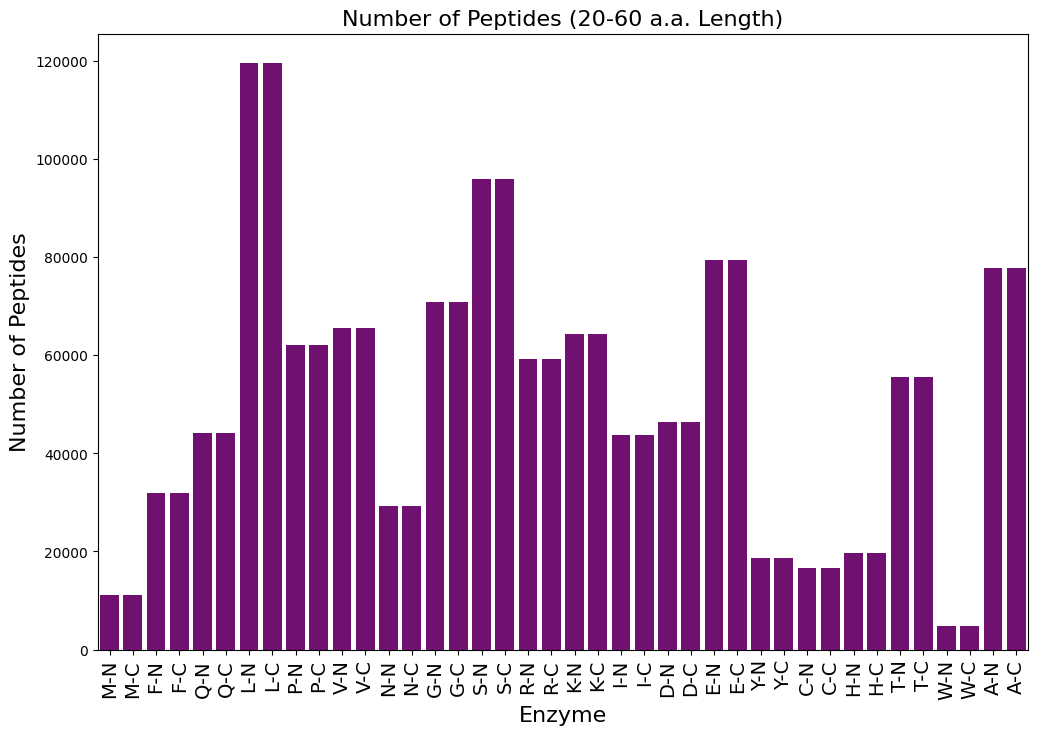

In [112]:
#generate a barplot of with the number of peptides generated for each enzyme
plt.figure(figsize=(12, 8))
enzymes = list(enzymes_dict.keys())
peptide_counts = [len(results[enzyme]) for enzyme in enzymes]
sns.barplot(x=enzymes, y=peptide_counts, color=bar_color)
plt.title(f'Number of Peptides ({min_len}-{max_len} a.a. Length)', fontsize=16)
plt.xlabel('Enzyme',fontsize=16)
plt.ylabel('Number of Peptides',fontsize=16)
plt.xticks(rotation=90,fontsize=14)


In [113]:
# Create a mapping of gene names to protein sequences
protein_sequence_map = subset_proteome.set_index('Gene')['Peptide'].to_dict()

# Function to calculate coverage
def calculate_coverage(group):
    gene = group.name  # Get the gene name from the group
    protein_sequence = protein_sequence_map[gene]  # Get the protein sequence
    peptides = group['peptide'].tolist()  # Generated peptides
    return silico.Pep2Pro(protein_sequence, peptides)

# Calculate coverage for each amino acid cleavage site
coverage_data = {}
for zyme in enzymes_dict.keys():
    print(f"Processing {zyme}...")
    # Filter data for current amino acid and site
    enzyme_df = results[zyme]
    # Calculate coverage for each protein
    coverage = enzyme_df.groupby('Gene').apply(calculate_coverage)
    coverage_data[zyme] = coverage

# Create coverage matrix
coverage_matrix = pd.DataFrame(coverage_data)
coverage_matrix = coverage_matrix * 100  # Convert to percentages
#generate a heatmap of the coverage of the amino acid cleavage sites


Processing M-N...


C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\3148381374.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = enzyme_df.groupby('Gene').apply(calculate_coverage)


Processing M-C...


C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\3148381374.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = enzyme_df.groupby('Gene').apply(calculate_coverage)


Processing F-N...


...

C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\3148381374.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = enzyme_df.groupby('Gene').apply(calculate_coverage)


Processing A-N...


C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\3148381374.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = enzyme_df.groupby('Gene').apply(calculate_coverage)


Processing A-C...


C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\3148381374.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = enzyme_df.groupby('Gene').apply(calculate_coverage)


In [55]:
# # Create heatmap
# plt.figure(figsize=(12, 8))
# sns.heatmap(coverage_matrix, 
#             annot=False,  # Show values
#             fmt='.0f',   # Format as float with 1 decimal
#             cmap='PRGn',  # Color scheme
#             cbar_kws={'label': 'Coverage (%)'})

# plt.title('Protein Coverage by Amino Acid-Cleavage Site')
# plt.xlabel('Amino Acid-Cleavage Site')
# plt.ylabel('Protein')
# plt.tight_layout()
# plt.show()

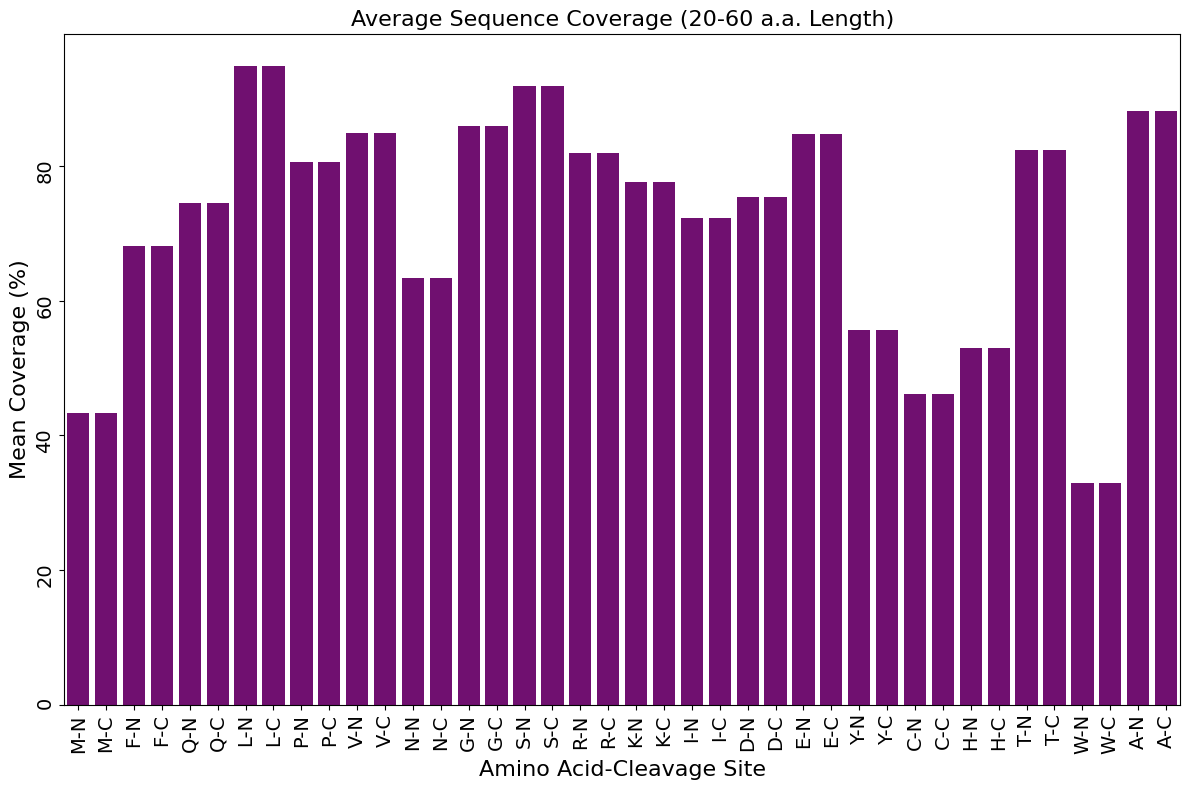

In [114]:
#calculate the mean coverage for each enzyme

coverage_matrix.mean()
#Graph the mean coverage for each enzyme
plt.figure(figsize=(12, 8))
sns.barplot(x=coverage_matrix.mean().index, y=coverage_matrix.mean().values,color=bar_color)
plt.title(f'Average Sequence Coverage ({min_len}-{max_len} a.a. Length)', fontsize=16)
plt.xlabel('Amino Acid-Cleavage Site',fontsize=16)
plt.ylabel('Mean Coverage (%)',fontsize=16)
plt.xticks(rotation=90,fontsize=14)
plt.yticks(fontsize=14,rotation=90)
plt.tight_layout()
plt.show()


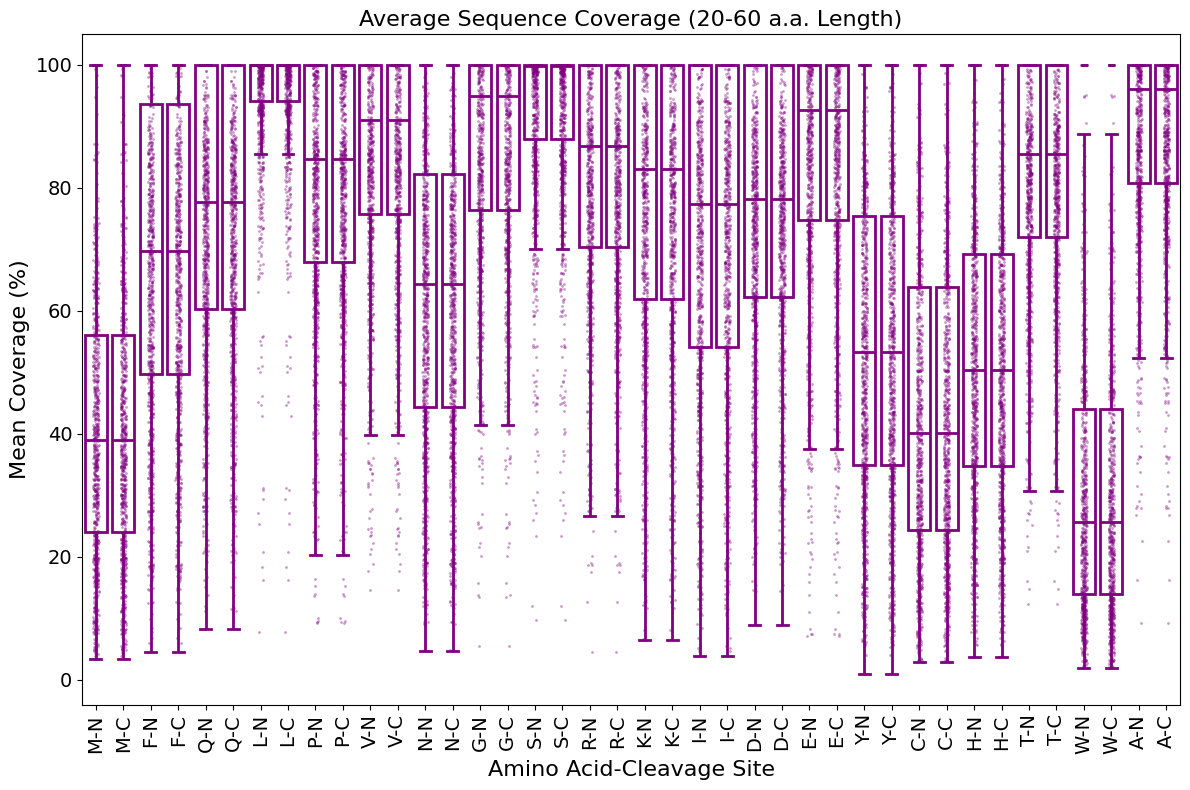


Enzyme Coverage Statistics:
M-N: Mean=43.41, Count=891
M-C: Mean=43.41, Count=891
F-N: Mean=68.13, Count=959
F-C: Mean=68.13, Count=959
Q-N: Mean=74.51, Count=984
Q-C: Mean=74.51, Count=984
L-N: Mean=94.87, Count=992
L-C: Mean=94.87, Count=992
P-N: Mean=80.57, Count=989
P-C: Mean=80.57, Count=989
V-N: Mean=84.99, Count=990
V-C: Mean=84.99, Count=990
N-N: Mean=63.41, Count=958
N-C: Mean=63.41, Count=958
G-N: Mean=86.01, Count=993
G-C: Mean=86.01, Count=993
S-N: Mean=91.98, Count=995
S-C: Mean=91.98, Count=995
R-N: Mean=82.04, Count=989
R-C: Mean=82.04, Count=989
K-N: Mean=77.60, Count=978
K-C: Mean=77.60, Count=978
I-N: Mean=72.28, Count=961
I-C: Mean=72.28, Count=961
D-N: Mean=75.49, Count=976
D-C: Mean=75.49, Count=976
E-N: Mean=84.79, Count=983
E-C: Mean=84.79, Count=983
Y-N: Mean=55.64, Count=946
Y-C: Mean=55.64, Count=946
C-N: Mean=46.12, Count=900
C-C: Mean=46.12, Count=900
H-N: Mean=52.92, Count=947
H-C: Mean=52.92, Count=947
T-N: Mean=82.36, Count=988
T-C: Mean=82.36, Count=988

In [115]:

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare data for boxplot
enzymes = coverage_matrix.columns
coverages_flat = []
enzyme_labels = []
means = []
for enzyme in enzymes:
    coverages = coverage_matrix[enzyme].dropna()  # Remove NaN values
    means.append(np.mean(coverages))
    for cov in coverages:
        enzyme_labels.append(enzyme)
        coverages_flat.append(cov)

# Create boxplot
sns.boxplot(x=enzyme_labels, y=coverages_flat, ax=ax, color='white', fliersize=0,linewidth=2,linecolor=bar_color)

# Overlay strip plot for individual coverage values
for enzyme in enzymes:
    coverages = coverage_matrix[enzyme].dropna()
    sns.stripplot(x=[enzyme]*len(coverages), y=coverages, ax=ax, color=bar_color, alpha=0.4, size=2, jitter=0.1)


ax.set_title(f'Average Sequence Coverage ({min_len}-{max_len} a.a. Length)', fontsize=16)
ax.set_xlabel('Amino Acid-Cleavage Site', fontsize=16)
ax.set_ylabel('Mean Coverage (%)', fontsize=16)
ax.tick_params(labelsize=14)
ax.tick_params(axis='x', rotation=90, labelsize=14)
plt.tight_layout()
plt.show()

# Print means for verification
print("\nEnzyme Coverage Statistics:")
for enzyme, mean in zip(enzymes, means):
    print(f"{enzyme}: Mean={mean:.2f}, Count={len(coverage_matrix[enzyme].dropna())}")

## Determine Frequency of Amino Acids in Selected Proteins

### Correlation to Mean Sequence Coverage

Text(0, 0.5, 'Frequency')

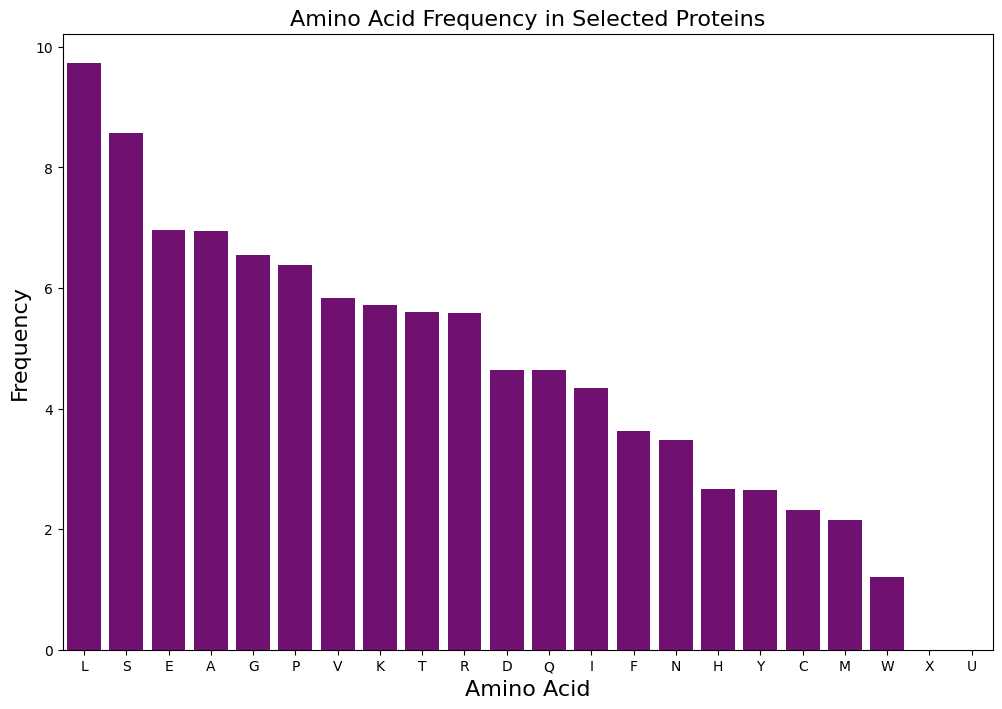

In [57]:
# from subset_proteome, select the proteins that are in the results dataframe
selected_proteins = subset_proteome

# selected protein determine the frequency of each amino acid
amino_acid_counts = selected_proteins['Peptide'].str.split('').explode().value_counts()


#divide the counts by the total number of amino acids in the protein
amino_acid_frequency = amino_acid_counts / amino_acid_counts.sum()
amino_acid_frequency = amino_acid_frequency.drop('')
amino_acid_frequency = amino_acid_frequency *100
# print(amino_acid_frequency)

#generate a barplot of the amino acid frequency
plt.figure(figsize=(12, 8))
sns.barplot(x=amino_acid_frequency.index, y=amino_acid_frequency.values,color="purple")
plt.title('Amino Acid Frequency in Selected Proteins', fontsize=16)
plt.xlabel('Amino Acid',fontsize=16)
plt.ylabel('Frequency',fontsize=16)

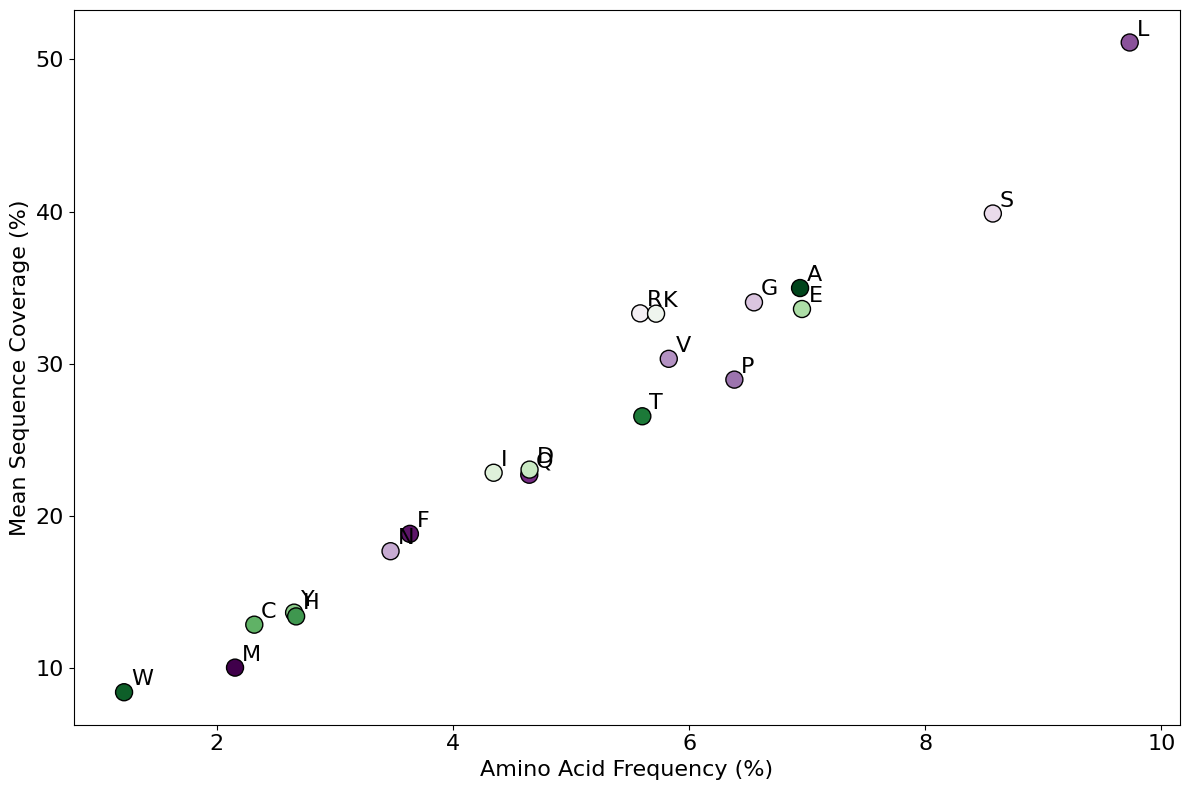

In [58]:
from adjustText import adjust_text
# Create dictionary mapping enzymes to their amino acid targets
enzyme_aa_map = {}
for enzyme in coverage_matrix.columns:
    if enzyme.endswith('-C'):  # Only keep C-terminal enzymes
        aa = enzyme.split('-')[0]
        if aa not in enzyme_aa_map:
            enzyme_aa_map[aa] = []
        enzyme_aa_map[aa].append(enzyme)

# Create lists for plotting
x_freq = []  # Amino acid frequencies
y_cov = []   # Mean coverages
labels = []  # Amino acid labels

for aa, enzymes in enzyme_aa_map.items():
    aa_freq = amino_acid_frequency[aa]
    for enzyme in enzymes:
        x_freq.append(aa_freq)
        y_cov.append(coverage_matrix[enzyme].mean())
        labels.append(aa)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(x_freq, y_cov, c=range(len(x_freq)), cmap='PRGn',s=150,linewidths=1,edgecolor='black')

# Add amino acid labels to each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_freq[i], y_cov[i]), xytext=(5, 5), textcoords='offset points',size=16)
plt.xlabel('Amino Acid Frequency (%)', fontsize=16)
plt.ylabel('Mean Sequence Coverage (%)', fontsize=16)
# plt.title('Amino Acid Frequency vs Mean Coverage (C-terminal Enzymes)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.colorbar(scatter, label='Enzyme Index')
plt.tight_layout()
plt.show()




In [59]:
# generate peptides from trypsin and thermolysin using 0, 2, 4 missed cleavages. 
# Dictionary to store results for each enzyme and missed cleavage combo
missed_cleavage_results = {}

enzymes_to_compare = [
    'thermolysin',
    'trypsin',
    'glutamyl endopeptidase'
]

missed_cleavages = [0, 2, 4]

for enzyme_name in enzymes_to_compare:
    missed_cleavage_results[enzyme_name] = {}
    
    for mc in missed_cleavages:
        print(f"Generating dataset for {enzyme_name} with {mc} missed cleavages...")
        silico.missed = mc # Update missed cleavages on object
        peptide_properties = silico.generate_samples(
            subset_proteome,
            enzyme=enzyme_name,
            target="Peptide", 
            identifier="Gene",
            pH=2.0,
            min_charge=2,
            max_length=60,
            min_length=7,
        )
        df = pd.DataFrame(peptide_properties)
        df['enzyme'] = enzyme_name
        df['missed_cleavages'] = mc
        missed_cleavage_results[enzyme_name][mc] = df


Generating dataset for thermolysin with 0 missed cleavages...
Proteolysis using thermolysin underway.
Generating peptides...
Generated 12842 peptides matching criteria.
Generating dataset for thermolysin with 2 missed cleavages...
Proteolysis using thermolysin underway.
Generating peptides...
Generated 150754 peptides matching criteria.
Generating dataset for thermolysin with 4 missed cleavages...
Proteolysis using thermolysin underway.
Generating peptides...
Generated 403758 peptides matching criteria.
Generating dataset for trypsin with 0 missed cleavages...
Proteolysis using trypsin underway.
Generating peptides...
Generated 25928 peptides matching criteria.
Generating dataset for trypsin with 2 missed cleavages...
Proteolysis using trypsin underway.
Generating peptides...
Generated 120711 peptides matching criteria.
Generating dataset for trypsin with 4 missed cleavages...
Proteolysis using trypsin underway.
Generating peptides...
Generated 210942 peptides matching criteria.
Genera

## Missed Cleavage Comparison (Thermolysin vs Trypsin vs GluC)

In [60]:
# generate peptides from trypsin and thermolysin using 0, 2, 4 missed cleavages. 
# Dictionary to store results for each enzyme and missed cleavage combo
missed_cleavage_results = {}

enzymes_to_compare = [
    'thermolysin',
    'trypsin',
    'glutamyl endopeptidase'
]

missed_cleavages = [0, 2, 4]

for enzyme_name in enzymes_to_compare:
    missed_cleavage_results[enzyme_name] = {}
    
    for mc in missed_cleavages:
        print(f"Generating dataset for {enzyme_name} with {mc} missed cleavages...")
        silico.missed = mc # Update missed cleavages on object
        peptide_properties = silico.generate_samples(
            subset_proteome,
            enzyme=enzyme_name,
            target="Peptide", 
            identifier="Gene",
            pH=2.0,
            min_charge=2,
            max_length=60,
            min_length=7,
        )
        df = pd.DataFrame(peptide_properties)
        df['enzyme'] = enzyme_name
        df['missed_cleavages'] = mc
        missed_cleavage_results[enzyme_name][mc] = df


Generating dataset for thermolysin with 0 missed cleavages...
Proteolysis using thermolysin underway.
Generating peptides...
Generated 12842 peptides matching criteria.
Generating dataset for thermolysin with 2 missed cleavages...
Proteolysis using thermolysin underway.
Generating peptides...
Generated 150754 peptides matching criteria.
Generating dataset for thermolysin with 4 missed cleavages...
Proteolysis using thermolysin underway.
Generating peptides...
Generated 403758 peptides matching criteria.
Generating dataset for trypsin with 0 missed cleavages...
Proteolysis using trypsin underway.
Generating peptides...
Generated 25928 peptides matching criteria.
Generating dataset for trypsin with 2 missed cleavages...
Proteolysis using trypsin underway.
Generating peptides...
Generated 120711 peptides matching criteria.
Generating dataset for trypsin with 4 missed cleavages...
Proteolysis using trypsin underway.
Generating peptides...
Generated 210942 peptides matching criteria.
Genera

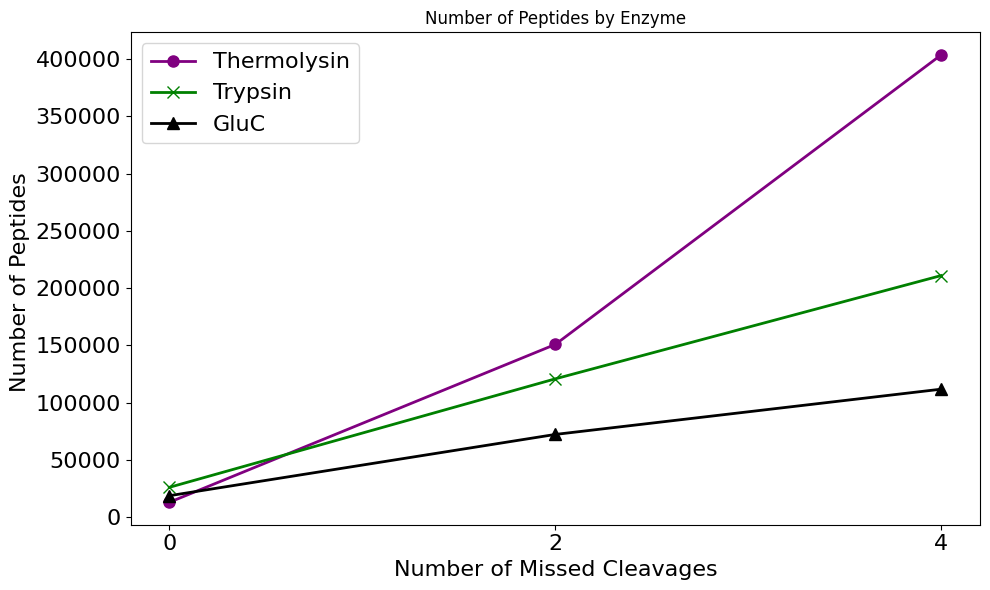

<Figure size 640x480 with 0 Axes>

In [61]:
## produce a line graph of both the thermolysin and trypsin number of peptides. The x axis should be missed cleavages and the y-axis number of peptides
fig, ax = plt.subplots(figsize=(10, 6))

# Get peptide counts for both enzymes
thermolysin_counts = [len(missed_cleavage_results['thermolysin'][mc]) for mc in missed_cleavages]
trypsin_counts = [len(missed_cleavage_results['trypsin'][mc]) for mc in missed_cleavages]
gluc_counts = [len(missed_cleavage_results['glutamyl endopeptidase'][mc]) for mc in missed_cleavages]
# Plot both lines on same axes
ax.plot(missed_cleavages, thermolysin_counts, marker='o', linewidth=2, markersize=8, color='purple', label='Thermolysin')
ax.plot(missed_cleavages, trypsin_counts, marker='x', linewidth=2, markersize=8, color='green', label='Trypsin')
ax.plot(missed_cleavages, gluc_counts, marker='^', linewidth=2, markersize=8, color='black', label='GluC')

ax.set_xlabel('Number of Missed Cleavages',fontsize=16)
ax.set_ylabel('Number of Peptides ', fontsize=16)
ax.set_title('Number of Peptides by Enzyme')
ax.grid(False)
ax.set_xticks(missed_cleavages)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()


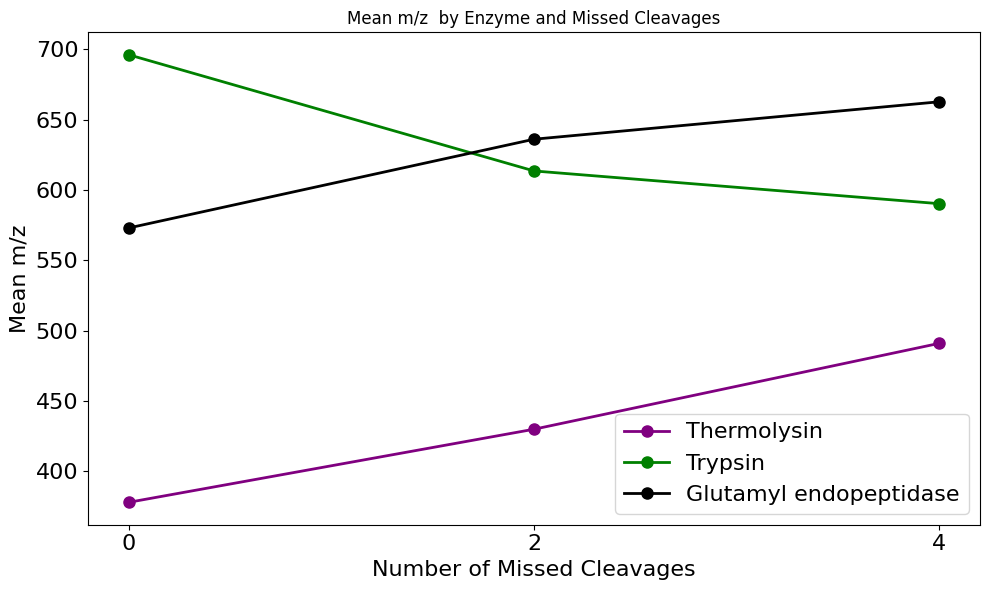

In [62]:
# Plot m/z distributions for each enzyme as missed cleavages increase
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'thermolysin': 'purple', 'trypsin': 'green','glutamyl endopeptidase':'black'}
for enzyme in ['thermolysin', 'trypsin',"glutamyl endopeptidase"]:
    # Calculate mean m/z for each missed cleavage level
    mean_mz = [missed_cleavage_results[enzyme][mc]['m/z'].mean() for mc in missed_cleavages]
    
    # Plot line
    ax.plot(missed_cleavages, mean_mz, marker='o', linewidth=2, markersize=8,
            color=colors[enzyme], label=enzyme.capitalize())

ax.set_xlabel('Number of Missed Cleavages',fontsize=16)
ax.set_ylabel('Mean m/z', fontsize=16)
ax.set_title('Mean m/z  by Enzyme and Missed Cleavages')
ax.grid(False)
ax.set_xticks(missed_cleavages)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()

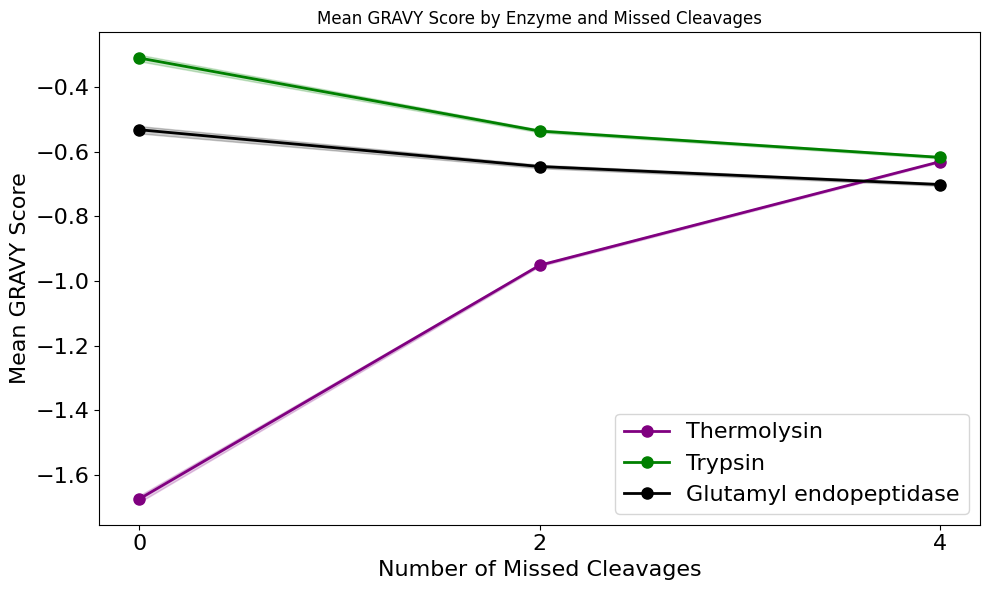

In [101]:
from scipy import stats

# Plot GRAVY distributions for each enzyme as missed cleavages increase
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'thermolysin': 'purple', 'trypsin': 'green', 'glutamyl endopeptidase': 'black'}
for enzyme in ['thermolysin', 'trypsin', 'glutamyl endopeptidase']:
    # Calculate mean GRAVY and confidence intervals for each missed cleavage level
    mean_mz = []
    ci_lower = []
    ci_upper = []
    for mc in missed_cleavages:
        gravy_scores = missed_cleavage_results[enzyme][mc]['GRAVY']
        mean = np.mean(gravy_scores)
        sem = stats.sem(gravy_scores)  # Standard error of the mean
        ci = sem * stats.t.ppf(0.975, len(gravy_scores) - 1)  # 95% CI
        mean_mz.append(mean)
        ci_lower.append(mean - ci)
        ci_upper.append(mean + ci)
    
    # Plot line
    ax.plot(missed_cleavages, mean_mz, marker='o', linewidth=2, markersize=8,
            color=colors[enzyme], label=enzyme.capitalize())
    
    # Add confidence interval as shaded band
    ax.fill_between(missed_cleavages, ci_lower, ci_upper, color=colors[enzyme], alpha=0.2)

ax.set_xlabel('Number of Missed Cleavages', fontsize=16)
ax.set_ylabel('Mean GRAVY Score', fontsize=16)
ax.set_title('Mean GRAVY Score by Enzyme and Missed Cleavages')
ax.grid(False)
ax.set_xticks(missed_cleavages)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()

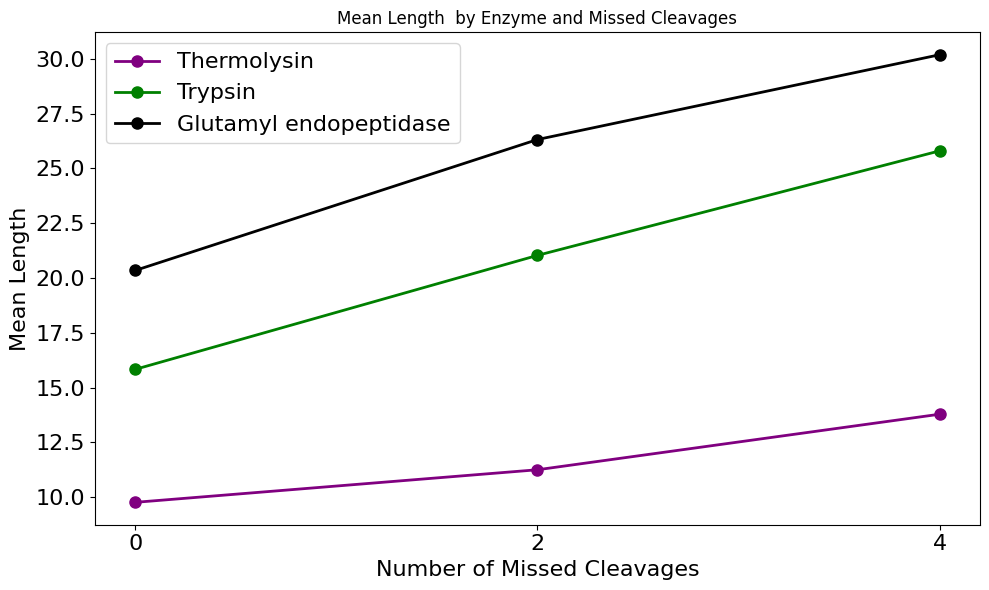

In [64]:
# Plot'Length distributions for each enzyme as missed cleavages increase
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'thermolysin': 'purple', 'trypsin': 'green','glutamyl endopeptidase':'black'}
for enzyme in ['thermolysin', 'trypsin',"glutamyl endopeptidase"]:
    # Calculate mean'Length for each missed cleavage level
    mean_mz = [missed_cleavage_results[enzyme][mc]['Length'].mean() for mc in missed_cleavages]
    
    # Plot line
    ax.plot(missed_cleavages, mean_mz, marker='o', linewidth=2, markersize=8,
            color=colors[enzyme], label=enzyme.capitalize())
ax.set_xlabel('Number of Missed Cleavages',fontsize=16)
ax.set_ylabel('Mean Length', fontsize=16)
ax.set_title('Mean Length  by Enzyme and Missed Cleavages')
ax.grid(False)
ax.set_xticks(missed_cleavages)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\2956410081.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = enzyme_mc_df.groupby('Gene').apply(calculate_coverage)
C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\2956410081.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = enzyme_mc_df.groupby('Gene').apply(calculate_coverage)
C:\Users\tcoop\AppData\Local\Temp\ipykernel_35288\29

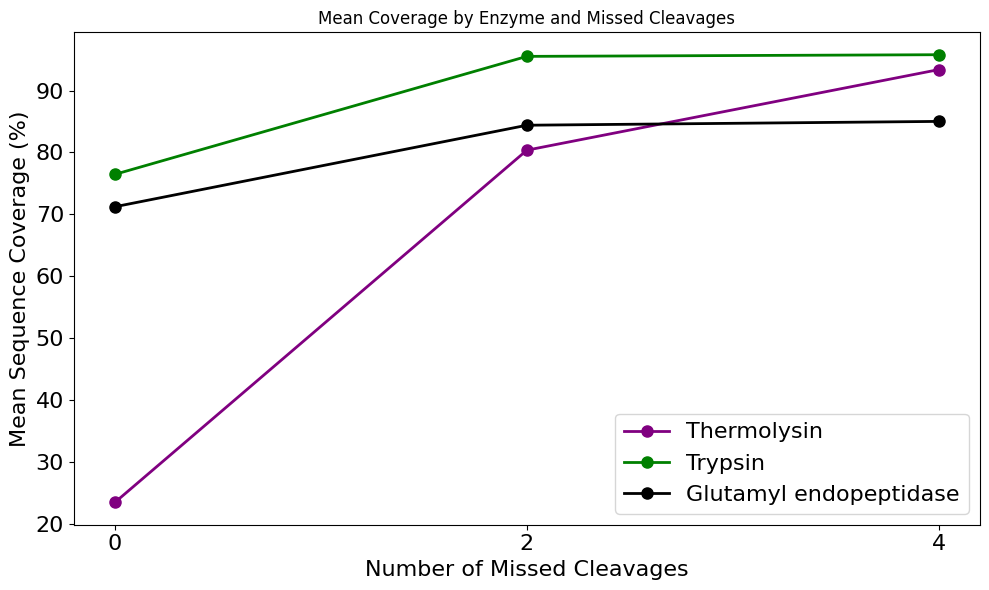

In [65]:
# Calculate coverage for each enzyme and missed cleavage level
coverage_data = {}
for enzyme in ['thermolysin', 'trypsin', 'glutamyl endopeptidase']:
    coverage_data[enzyme] = {}
    for mc in missed_cleavages:
        # Filter data for current enzyme and MC level
        enzyme_mc_df = missed_cleavage_results[enzyme][mc]
        # Calculate coverage for each protein
        coverage = enzyme_mc_df.groupby('Gene').apply(calculate_coverage)
        coverage_data[enzyme][mc] = coverage

# Plot sequence coverage distributions
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'thermolysin': 'purple', 'trypsin': 'green','glutamyl endopeptidase':'black'}
for enzyme in ['thermolysin', 'trypsin',"glutamyl endopeptidase"]:
    # Calculate mean coverage for each MC level
    mean_coverage = [coverage_data[enzyme][mc].mean() * 100 for mc in missed_cleavages]
    
    # Plot line
    ax.plot(missed_cleavages, mean_coverage, marker='o', linewidth=2, markersize=8,
            color=colors[enzyme], label=enzyme.capitalize())

ax.set_xlabel('Number of Missed Cleavages',fontsize=16)
ax.set_ylabel('Mean Sequence Coverage (%)', fontsize=16)
ax.set_title('Mean Coverage by Enzyme and Missed Cleavages')
ax.grid(False)
ax.set_xticks(missed_cleavages)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()


## Missed Cleavage Bioinformatics

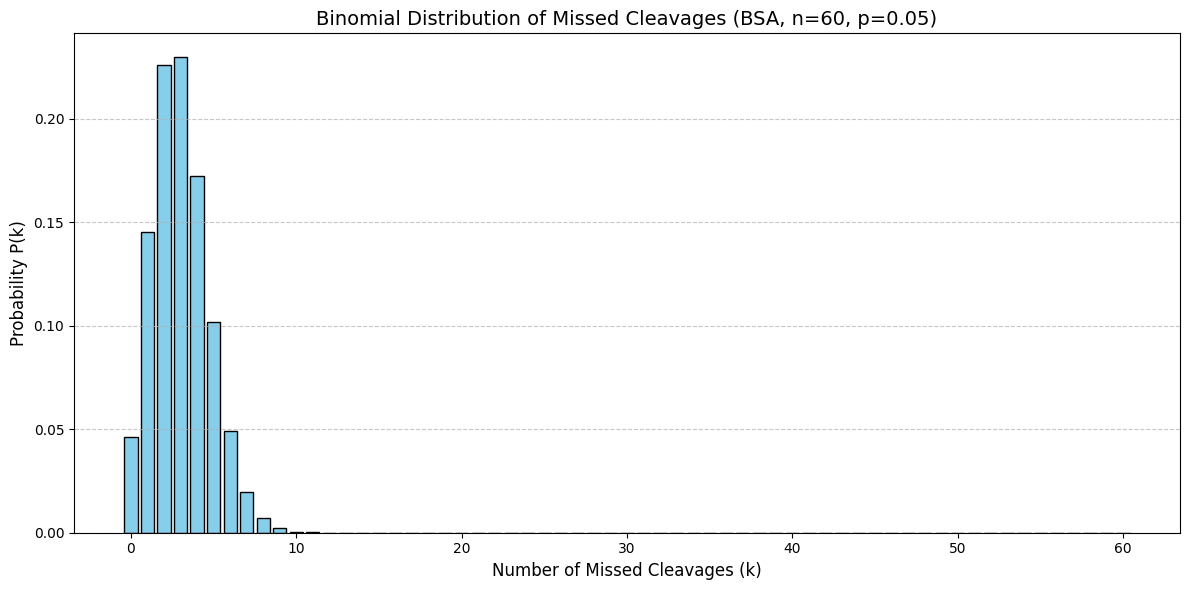

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters
n = 60           # Number of cleavage sites
p = 0.05         # Probability of missed cleavage (i.e., 5% failure)

# Values of k: number of missed cleavages
k_values = np.arange(0, n + 1)

# Compute binomial probabilities
probabilities = binom.pmf(k_values, n, p)

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(k_values, probabilities, color='skyblue', edgecolor='black')
plt.title('Binomial Distribution of Missed Cleavages (BSA, n=60, p=0.05)', fontsize=14)
plt.xlabel('Number of Missed Cleavages (k)', fontsize=12)
plt.ylabel('Probability P(k)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


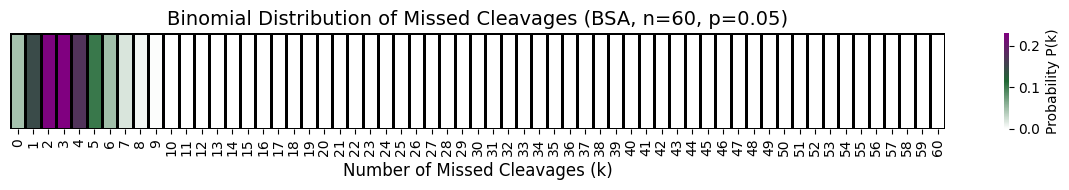

In [129]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import binom

# Parameters
n = 60           # Number of cleavage sites
p = 0.05         # Probability of missed cleavage (i.e., 5% failure)

# Values of k: number of missed cleavages
k_values = np.arange(0, n + 1)

# Compute binomial probabilities
probabilities = binom.pmf(k_values, n, p)

# Create custom colormap from green (0) to purple (max)
colors = ["#ffffff","#206734", "#800080"]  # Green to purple
cmap = LinearSegmentedColormap.from_list('GreenToPurple', colors)

# Create data for heatmap (1D array reshaped to 1 x n+1)
data = probabilities.reshape(1, -1)

# Create figure
plt.figure(figsize=(12, 2))

# Create heatmap with custom colormap
sns.heatmap(data, cmap=cmap, cbar_kws={'label': 'Probability P(k)'}, 
            xticklabels=k_values, yticklabels=[''], vmin=0, 
            annot=False, fmt='.2e', annot_kws={'size': 8},
            linewidths=1, linecolor='black')

# Customize plot
plt.title('Binomial Distribution of Missed Cleavages (BSA, n=60, p=0.05)', fontsize=14)
plt.xlabel('Number of Missed Cleavages (k)', fontsize=12)
plt.ylabel('', fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.yticks([])
plt.tight_layout()
plt.show()

## Distance of Cleavage Sites from Each Other. 


Trypsin Pair Distances:
K-R: Median=20.00, SD=22.90, Count=128785
R-R: Median=20.00, SD=25.99, Count=77635
K-K: Median=19.00, SD=21.04, Count=82405

Thermolysin Pair Distances:
F-M: Median=8.00, SD=6.97, Count=12447
L-M: Median=8.00, SD=6.52, Count=32145
M-V: Median=8.00, SD=6.55, Count=19548
F-L: Median=8.00, SD=6.53, Count=56177
F-V: Median=8.00, SD=6.54, Count=34354
A-F: Median=8.00, SD=7.48, Count=36506
L-V: Median=8.00, SD=6.46, Count=90290
L-L: Median=8.00, SD=6.48, Count=80914
A-L: Median=8.00, SD=6.71, Count=107785
A-V: Median=8.00, SD=6.86, Count=64180
V-V: Median=8.00, SD=6.61, Count=29487
I-V: Median=8.00, SD=6.50, Count=41625
I-L: Median=8.00, SD=6.43, Count=67318
A-I: Median=8.00, SD=6.66, Count=42980
I-I: Median=8.00, SD=6.49, Count=17861
F-I: Median=8.00, SD=6.39, Count=27807
F-F: Median=8.00, SD=7.07, Count=12657
A-A: Median=8.00, SD=7.14, Count=46442
A-M: Median=8.00, SD=7.76, Count=22134
I-M: Median=8.00, SD=6.41, Count=15084
M-M: Median=8.00, SD=7.59, Count=3975

Gl

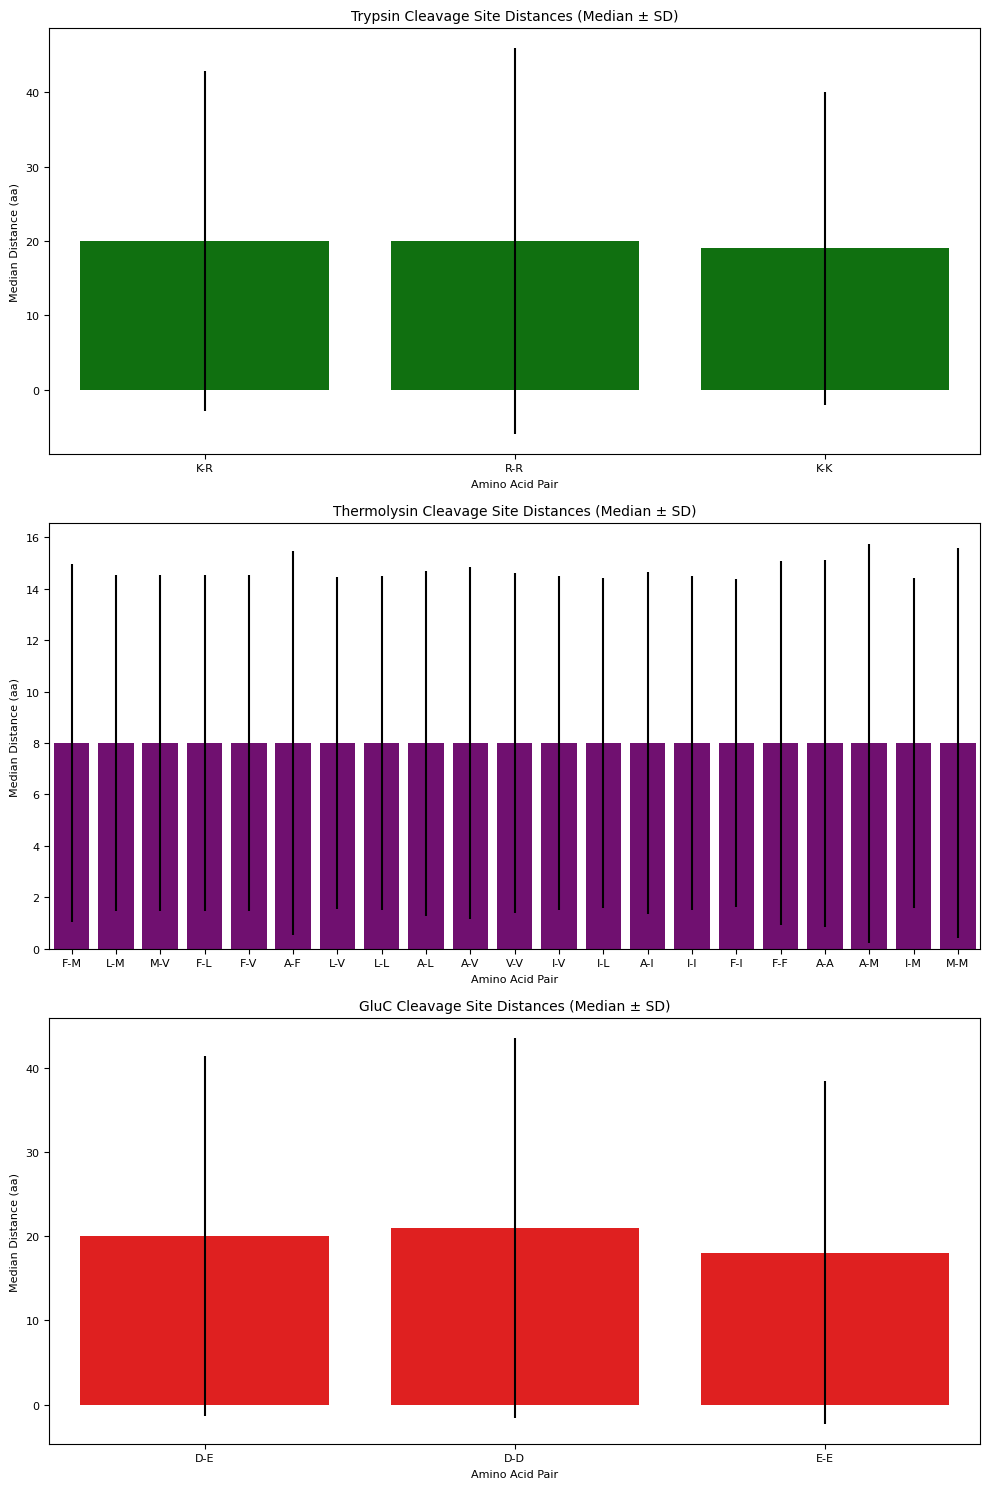

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define enzyme cleavage sites
enzyme_sites = {
    'Trypsin': ['K', 'R'],
    'Thermolysin': ['F', 'M', 'V', 'A', 'I', 'L'],
    'GluC': ["D", "E"]
}

def pairwise_cleavage_distances(sequence, aa_list, max_positions_apart=5):
    """Calculate distances between cleavage sites up to max_positions_apart."""
    positions = [(i, aa) for i, aa in enumerate(sequence) if aa in aa_list]
    if len(positions) < 2:
        return {}
    distances = {}
    for i in range(len(positions)):
        for j in range(i+1, min(i+max_positions_apart+1, len(positions))):
            pos1, aa1 = positions[i]
            pos2, aa2 = positions[j]
            pair = tuple(sorted([aa1, aa2]))
            if pair not in distances:
                distances[pair] = []
            distances[pair].append(pos2 - pos1)
    return distances

# Create figure with subplots for each enzyme
fig, axes = plt.subplots(len(enzyme_sites), 1, figsize=(10, 15))
if len(enzyme_sites) == 1:
    axes = [axes]

colors = ['green', 'purple', 'red']
for idx, (enzyme, sites) in enumerate(enzyme_sites.items()):
    # Calculate distances for all sequences
    all_pair_distances = {}
    for sequence in subset_proteome['Peptide']:
        distances = pairwise_cleavage_distances(sequence, sites, max_positions_apart=5)
        for pair, dist_list in distances.items():
            if pair not in all_pair_distances:
                all_pair_distances[pair] = []
            all_pair_distances[pair].extend(dist_list)
    
    # Calculate median and SD for each pair
    pairs = []
    medians = []
    stds = []
    for pair, distances in all_pair_distances.items():
        pairs.append(f"{pair[0]}-{pair[1]}")
        medians.append(np.median(distances))
        stds.append(np.std(distances) if len(distances) > 1 else 0)  # SD requires >1 value
    
    # Create bar plot with error bars for SD
    sns.barplot(x=pairs, y=medians, yerr=stds, ax=axes[idx], color=colors[idx])
    axes[idx].set_title(f'{enzyme} Cleavage Site Distances (Median ± SD)', fontsize=10)
    axes[idx].set_xlabel('Amino Acid Pair', fontsize=8)
    axes[idx].set_ylabel('Median Distance (aa)', fontsize=8)
    axes[idx].tick_params(labelsize=8)
    axes[idx].tick_params(axis='x', rotation=0)
    
    # Print medians and SDs for verification
    print(f"\n{enzyme} Pair Distances:")
    for pair, median, sd in zip(pairs, medians, stds):
        print(f"{pair}: Median={median:.2f}, SD={sd:.2f}, Count={len(all_pair_distances[tuple(pair.split('-'))])}")

plt.tight_layout()
plt.show()


Trypsin Pair Distances:
K-R: Mean=8.79, Count=25969
K-K: Mean=8.08, Count=17279
R-R: Mean=8.90, Count=16501

Thermolysin Pair Distances:
F-M: Mean=3.22, Count=2353
F-L: Mean=3.09, Count=11304
L-V: Mean=3.03, Count=18026
L-L: Mean=3.04, Count=16596
A-L: Mean=3.01, Count=21757
A-V: Mean=3.03, Count=13017
I-V: Mean=3.08, Count=8401
I-L: Mean=3.06, Count=13559
F-I: Mean=3.05, Count=5796
F-F: Mean=3.18, Count=2579
A-F: Mean=3.03, Count=7281
F-V: Mean=3.00, Count=7041
I-I: Mean=3.03, Count=3721
A-A: Mean=3.02, Count=9676
A-I: Mean=3.11, Count=8333
A-M: Mean=2.94, Count=4633
V-V: Mean=3.09, Count=6019
I-M: Mean=3.12, Count=3006
L-M: Mean=3.15, Count=6448
M-V: Mean=3.01, Count=3935
M-M: Mean=2.97, Count=861

GluC Pair Distances:
D-E: Mean=8.52, Count=27739
E-E: Mean=7.73, Count=22926
D-D: Mean=8.99, Count=10694


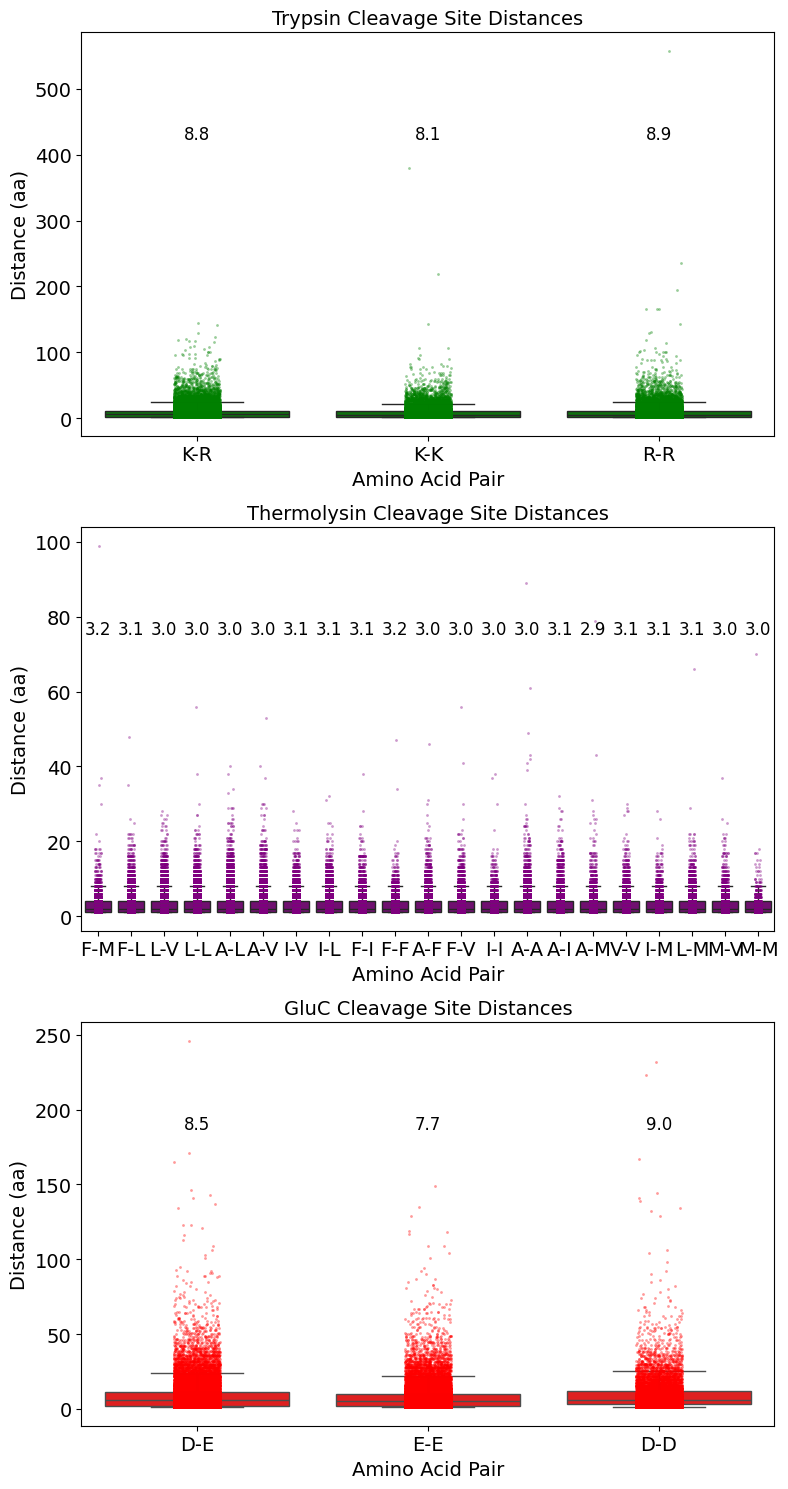

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define enzyme cleavage sites
enzyme_sites = {
    'Trypsin': ['K', 'R'],
    'Thermolysin': ['F', 'M', 'V', 'A', 'I', 'L'],
    'GluC': ["D", "E"]
}

def pairwise_cleavage_distances(sequence, aa_list, max_positions_apart=5):
    """Calculate distances between cleavage sites up to max_positions_apart."""
    positions = [(i, aa) for i, aa in enumerate(sequence) if aa in aa_list]
    if len(positions) < 2:
        return {}
    distances = {}
    for i in range(len(positions)):
        for j in range(i+1, min(i+max_positions_apart+1, len(positions))):
            pos1, aa1 = positions[i]
            pos2, aa2 = positions[j]
            pair = tuple(sorted([aa1, aa2]))
            if pair not in distances:
                distances[pair] = []
            distances[pair].append(pos2 - pos1)
    return distances

# Create figure with subplots for each enzyme
fig, axes = plt.subplots(len(enzyme_sites), 1, figsize=(8, 15))
if len(enzyme_sites) == 1:
    axes = [axes]

colors = ['green', 'purple', 'red']
for idx, (enzyme, sites) in enumerate(enzyme_sites.items()):
    # Collect distances for all sequences
    all_pair_distances = {}
    pair_protein_distances = {}
    for seq_idx, sequence in enumerate(subset_proteome['Peptide']):
        distances = pairwise_cleavage_distances(sequence, sites, max_positions_apart=1)
        for pair, dist_list in distances.items():
            if pair not in all_pair_distances:
                all_pair_distances[pair] = []
                pair_protein_distances[pair] = []
            all_pair_distances[pair].extend(dist_list)
            pair_protein_distances[pair].extend([(seq_idx, dist) for dist in dist_list])
    
    # Prepare data for boxplot
    pairs_flat = []
    distances_flat = []
    means = []
    for pair in all_pair_distances:
        pair_label = f"{pair[0]}-{pair[1]}"
        dists = all_pair_distances[pair]
        means.append(np.mean(dists))
        for dist in dists:
            pairs_flat.append(pair_label)
            distances_flat.append(dist)
    
    # Create boxplot
    sns.boxplot(x=pairs_flat, y=distances_flat, ax=axes[idx], color=colors[idx], fliersize=0)
    
    # Overlay strip plot for individual protein distances
    for pair in all_pair_distances:
        pair_label = f"{pair[0]}-{pair[1]}"
        protein_distances = pair_protein_distances.get(pair, [])
        if protein_distances:
            protein_dists = [dist for _, dist in protein_distances]
            sns.stripplot(x=[pair_label]*len(protein_dists), y=protein_dists, 
                         ax=axes[idx], color=colors[idx], alpha=0.4, size=2, jitter=0.1)
    
    # Add mean text above each box plot
    for i, (pair, mean) in enumerate(zip(pairs_flat[::len(distances_flat)//len(set(pairs_flat))], means)):
        axes[idx].text(i, max(distances_flat)*0.75, f'{mean:.1f}', ha='center', va='bottom', fontsize=12)
    
    axes[idx].set_title(f'{enzyme} Cleavage Site Distances', fontsize=14)
    axes[idx].set_xlabel('Amino Acid Pair', fontsize=14)
    axes[idx].set_ylabel('Distance (aa)', fontsize=14)
    axes[idx].tick_params(labelsize=14)
    axes[idx].tick_params(axis='x', rotation=0, labelsize=14)
    
    # Print means for verification
    print(f"\n{enzyme} Pair Distances:")
    for pair in all_pair_distances:
        pair_label = f"{pair[0]}-{pair[1]}"
        dists = all_pair_distances[pair]
        print(f"{pair_label}: Mean={np.mean(dists):.2f}, Count={len(dists)}")

plt.tight_layout()
plt.show()

In [ ]:
# Example sequence

def pairwise_cleavage_distances(sequence, aa_list):
    """Calculate distances between cleavage sites up to 2 positions away."""
    positions = [(i, aa) for i, aa in enumerate(sequence) if aa in aa_list]
    if len(positions) < 2:
        return {}

    distances = {}
    for i in range(len(positions)):
        for j in range(i+1, min(i+2, len(positions))):
            pos1, aa1 = positions[i]
            pos2, aa2 = positions[j]
            pair = tuple(sorted([aa1, aa2]))  # Sort to avoid duplicates
            if pair not in distances:
                distances[pair] = []
            distances[pair].append(pos2 - pos1)

    return distances

example_seq = "TTTKKTTLTTRTTTTTKFMTTTVTTTVTTTKTTTAITTILTMTTM"
example_sites = ['F', 'M','V',"A","I","L"] # Using some common protease sites






# Calculate distances
example_distances = pairwise_cleavage_distances(example_seq, example_sites)

print("Example sequence:", example_seq)
print("\nCleavage site positions:")
for aa in example_sites:
    positions = [i for i, c in enumerate(example_seq) if c == aa]
    print(f"{aa}: {positions}")
    
print("\nPairwise distances:")
for pair, distances in sorted(example_distances.items()):
    mean_dist = sum(distances) / len(distances) if distances else 0
    print(f"{pair}: {distances} (mean: {mean_dist:.1f})")

# Print pairs with no distances found
all_pairs = [(a,b) for i,a in enumerate(example_sites) for b in example_sites[i:]]
missing_pairs = set(all_pairs) - set(example_distances.keys())
if missing_pairs:
    print("\nPairs with no distances found:")
    for pair in sorted(missing_pairs):
        print(f"{pair}")


Example sequence: TTTKKTTLTTRTTTTTKFMTTTVTTTVTTTKTTTAITTILTMTTM

Cleavage site positions:
F: [17]
M: [18, 41, 44]
V: [22, 26]
A: [34]
I: [35, 38]
L: [7, 39]

Pairwise distances:
('A', 'I'): [1] (mean: 1.0)
('A', 'V'): [8] (mean: 8.0)
('F', 'L'): [10] (mean: 10.0)
('F', 'M'): [1] (mean: 1.0)
('I', 'I'): [3] (mean: 3.0)
('I', 'L'): [1] (mean: 1.0)
('L', 'M'): [2] (mean: 2.0)
('M', 'M'): [3] (mean: 3.0)
('M', 'V'): [4] (mean: 4.0)
('V', 'V'): [4] (mean: 4.0)

Pairs with no distances found:
('A', 'A')
('A', 'L')
('F', 'A')
('F', 'F')
('F', 'I')
('F', 'V')
('L', 'L')
('M', 'A')
('M', 'I')
('M', 'L')
('V', 'A')
('V', 'I')
('V', 'L')


In [72]:
def pairwise_cleavage_distances(sequence, aa_list):
    """Calculate distances between all cleavage site pairs."""
    positions = [(i, aa) for i, aa in enumerate(sequence) if aa in aa_list]
    if len(positions) < 2:
        return {}

    distances = {}
    for i in range(len(positions)):
        for j in range(i+1, len(positions)):  # Consider all subsequent positions
            pos1, aa1 = positions[i]
            pos2, aa2 = positions[j]
            pair = tuple(sorted([aa1, aa2]))  # Sort to avoid duplicates
            if pair not in distances:
                distances[pair] = []
            distances[pair].append(pos2 - pos1)

    return distances

In [73]:
example_seq = "TTTKKTTLTTRTTTTTKFMTTTVTTTVTTTKTTTAITTILTMTTM"
example_sites = ['F', 'M', 'V', 'A', 'I', 'L']
example_distances = pairwise_cleavage_distances(example_seq, example_sites)

print("Example sequence:", example_seq)
print("\nCleavage site positions:")
for aa in example_sites:
    positions = [i for i, c in enumerate(example_seq) if c == aa]
    print(f"{aa}: {positions}")
    
print("\nPairwise distances:")
for pair, distances in sorted(example_distances.items()):
    mean_dist = sum(distances) / len(distances) if distances else 0
    print(f"{pair}: {distances} (mean: {mean_dist:.1f})")

all_pairs = [(a, b) for i, a in enumerate(example_sites) for b in example_sites[i:]]
missing_pairs = set(all_pairs) - set(example_distances.keys())
if missing_pairs:
    print("\nPairs with no distances found:")
    for pair in sorted(missing_pairs):
        print(f"{pair}")

Example sequence: TTTKKTTLTTRTTTTTKFMTTTVTTTVTTTKTTTAITTILTMTTM

Cleavage site positions:
F: [17]
M: [18, 41, 44]
V: [22, 26]
A: [34]
I: [35, 38]
L: [7, 39]

Pairwise distances:
('A', 'F'): [17] (mean: 17.0)
('A', 'I'): [1, 4] (mean: 2.5)
('A', 'L'): [27, 5] (mean: 16.0)
('A', 'M'): [16, 7, 10] (mean: 11.0)
('A', 'V'): [12, 8] (mean: 10.0)
('F', 'I'): [18, 21] (mean: 19.5)
('F', 'L'): [10, 22] (mean: 16.0)
('F', 'M'): [1, 24, 27] (mean: 17.3)
('F', 'V'): [5, 9] (mean: 7.0)
('I', 'I'): [3] (mean: 3.0)
('I', 'L'): [28, 31, 4, 1] (mean: 16.0)
('I', 'M'): [17, 20, 6, 9, 3, 6] (mean: 10.2)
('I', 'V'): [13, 16, 9, 12] (mean: 12.5)
('L', 'L'): [32] (mean: 32.0)
('L', 'M'): [11, 34, 37, 21, 2, 5] (mean: 18.3)
('L', 'V'): [15, 19, 17, 13] (mean: 16.0)
('M', 'M'): [23, 26, 3] (mean: 17.3)
('M', 'V'): [4, 8, 19, 22, 15, 18] (mean: 14.3)
('V', 'V'): [4] (mean: 4.0)

Pairs with no distances found:
('A', 'A')
('F', 'A')
('F', 'F')
('M', 'A')
('M', 'I')
('M', 'L')
('V', 'A')
('V', 'I')
('V', 'L')
